In [1]:
import numpy as np
import random

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import albumentations as A

%load_ext autoreload
%autoreload 2

/Users/alessioarcara/miniforge3/envs/ml4cv_ass/lib/python3.11/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()



Premessa: come il mio precedente notebook, link al notebook, sono interessato ad avere delle reti efficienti che mi permettano di poter trainare liberamente e fare diverse prove anche su un dispositivo mac con `mps`.

Guardando i diversi paper che ottenevano alti score nel benchmark SegmentMeIfYouCan, i migliori come mIoU utilizzano Mask classification e di conseguenza Mask2Former con l'aggiunta di un modulo o di tecniche per aggiungere anche il rilevamento di anomalie. Tra tutti ho preferito implementare il paper `Open Semantic Segmentation with Class Similarity` che ottiene un mIoU competitivo, rimanendo al contempo veloce a differenza degli approcci con Mask2Former più lenti di natura, e con un rilevamento di anomalie decisamente migliore. Successivamente, data la recente uscita del paper `Open Panoptic Segmentation`, sempre degli stessi autori, che oltre ad aggiungere la Panoptic Segmentation, risolve alcuni problemi del precedente approccio.

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 CUDA device is available!")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🍎 MPS device is available!")
else:
    device = torch.device("cpu")
    print("🐢 No GPU available. Falling back to the CPU.")

🍎 MPS device is available!


In [3]:
def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(seed=0)

In [24]:
from data.streethazards import StreetHazards
from pathlib import Path

root_dir = Path("/Users/alessioarcara/Downloads/universita/AI/ml4cv-assignment/data/datasets/train")
subset="training/t1-3/"
train_data = StreetHazards(root_dir, subset)

print(f"Number of training samples: {len(train_data)}")

Number of training samples: 5125


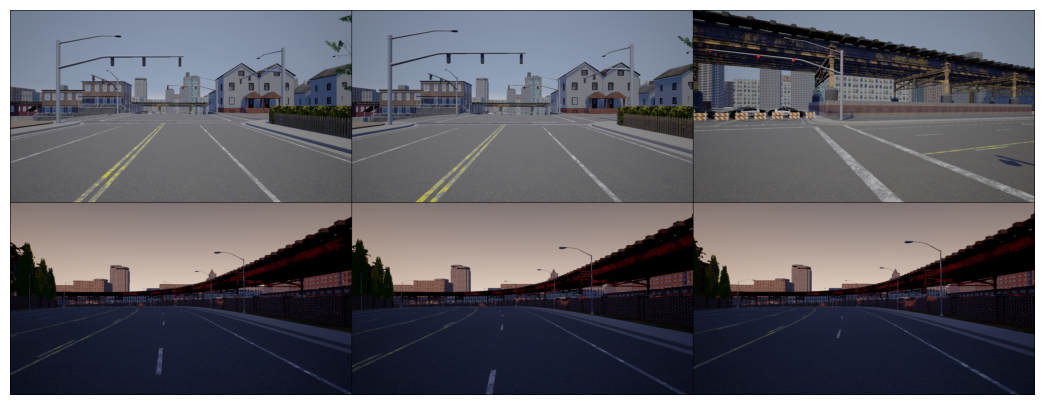

In [47]:
from torchvision.utils import make_grid

NUM_IMAGES = 6
grid = make_grid([train_data[i][0] for i in range(NUM_IMAGES)], nrow=3)

grid_image = grid.permute(1, 2, 0)

plt.figure(figsize=(15, 5))
plt.imshow(grid_image.numpy())
plt.axis('off')
plt.show()


In [32]:
torch.tensor(train_data[0][1])

RuntimeError: Could not infer dtype of PngImageFile

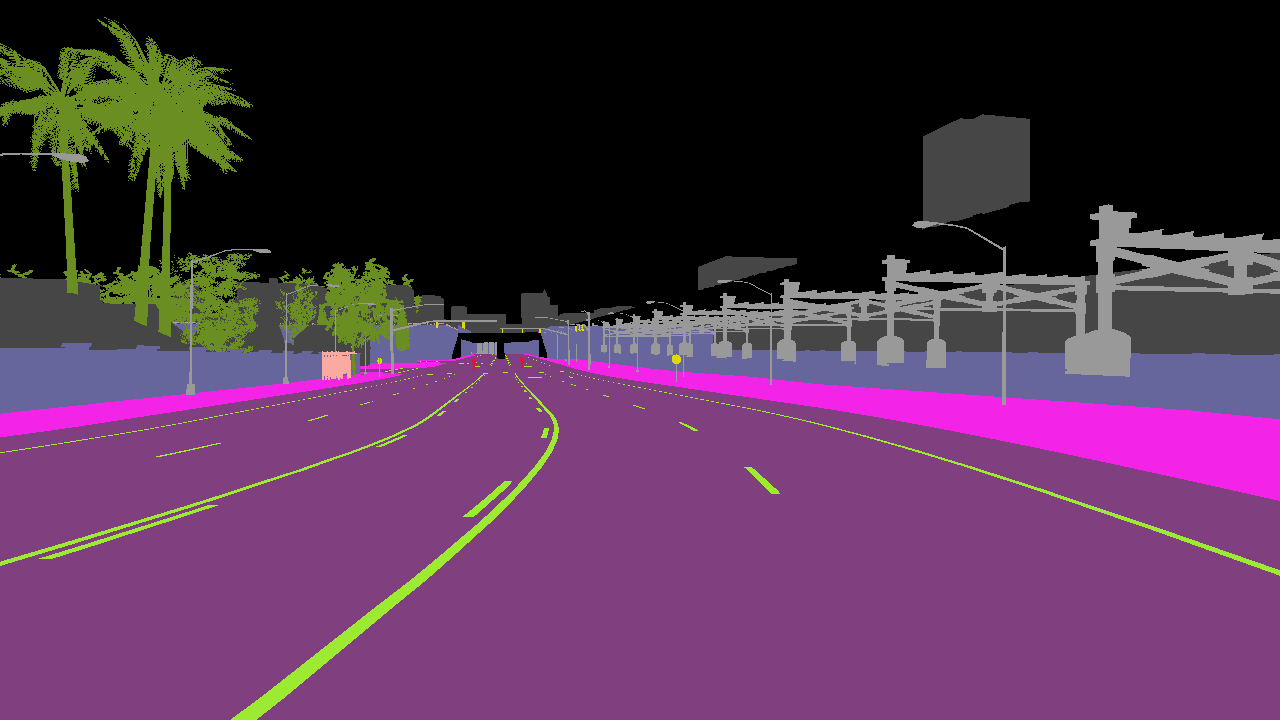

In [26]:
from utils.visualize import color, COLORS

color(train_data[100][2], COLORS)

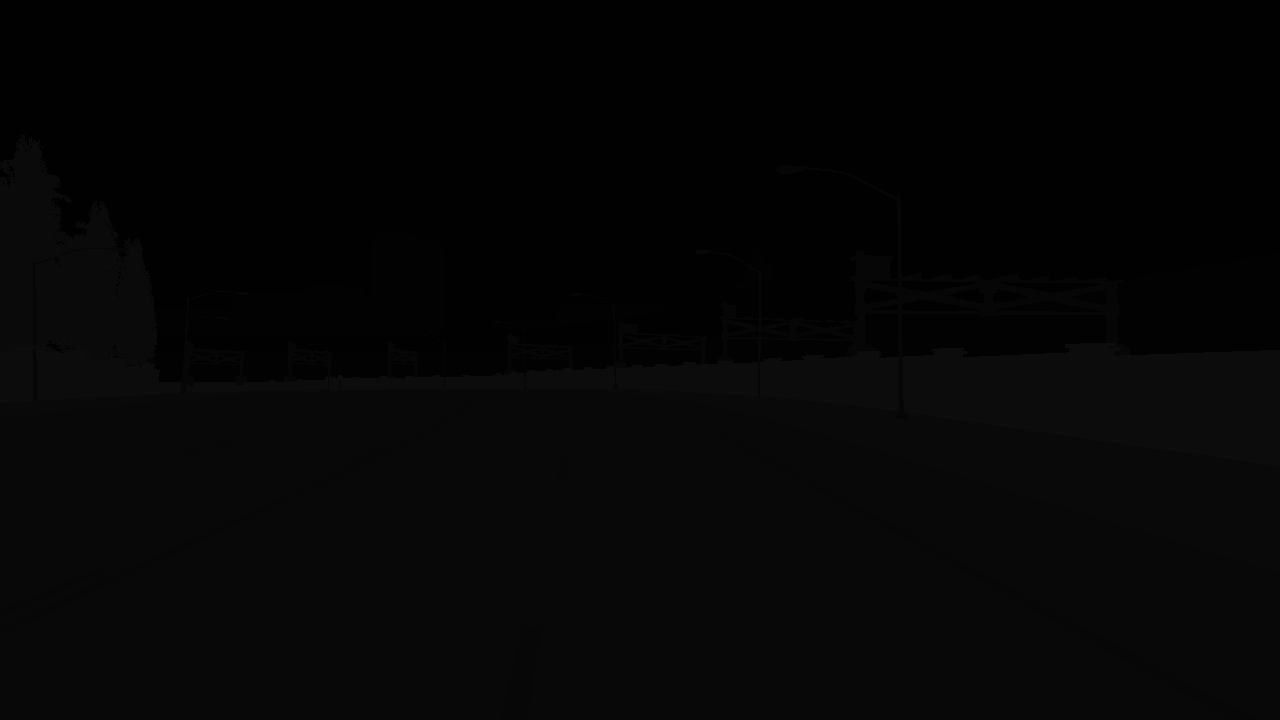

In [27]:
train_data[4][1]

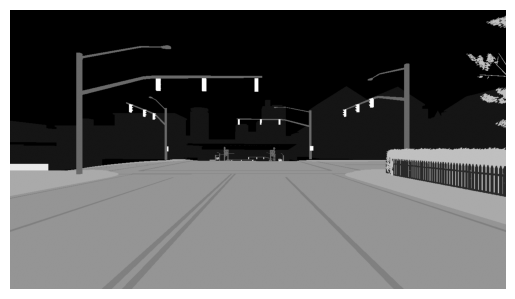

In [14]:
plt.imshow(torch.permute(train_data[0][1], (1, 2, 0)), cmap='gray')
plt.axis('off')
plt.show()

nel training devo vedere due metriche mIoU, mAP, F1 score? e 